# Chapter 43 — Synchrotron Radiation: the Non-Thermal Radio Continuum

!!! info "Before you start"
    **Prerequisites:** Ch 2 (The Physics of Radio Emission), Ch 1 (What is Radio Astronomy?) · **Maths Lab:** none · **~45 min** · **Intermediate**

In [Chapter 2](02_physics_of_radio_emission.ipynb) we met two flavours of radio emission
and used the **spectral index** $\alpha$ to tell them apart. Thermal free–free gas gives
a nearly flat spectrum ($\alpha \approx -0.1$); everything else — the steep, non-thermal
tail — was labelled *synchrotron* and left as a promise for later. This chapter keeps
that promise.

**Synchrotron radiation** is produced by **relativistic electrons spiralling in magnetic
fields**. It dominates the non-thermal radio sky: supernova remnants, AGN jets and lobes,
radio galaxies, and the diffuse Galactic background all shine primarily by this mechanism.
The physics is elegant: a **power-law electron energy distribution**
$N(E) \propto E^{-p}$ — the natural output of diffusive shock acceleration — maps directly
onto a **power-law flux spectrum** $S_\nu \propto \nu^{\alpha}$ with
$\alpha = -(p-1)/2$. Reading the spectral index backwards gives the electron index, and
the electron index tells you about the acceleration process.

We deepen Ch 2 in every direction: we derive where $\alpha$ comes from, explain why
compact sources self-absorb at low frequency (synchrotron self-absorption), show how the
spectrum steepens as electrons age (spectral aging), estimate the magnetic field from the
luminosity alone (equipartition), and explain why apparent brightness temperatures above
$10^{12}$ K demand relativistic beaming rather than a hotter source. The real spectrum of
**Cassiopeia A**, the brightest radio source in the sky (after the Sun), lets us measure
all of this from data.

## Learning goals

By the end of this chapter you will be able to:

- **Relate** the observed synchrotron spectral index $\alpha$ to the electron power-law
  index $p$ via $\alpha = -(p-1)/2$, and invert it.
- **Explain** synchrotron self-absorption (SSA) and why compact sources show a
  characteristic $\nu^{5/2}$ low-frequency slope below the turnover.
- **Describe** spectral aging: why radiative losses steepen the high-frequency spectrum
  above a break frequency, and how to estimate a source's radiative age.
- **Apply** the minimum-energy (equipartition) argument to estimate the magnetic field
  in a radio galaxy.
- **Recognise** the $\sim 10^{12}$ K brightness-temperature limit and its implication
  for Doppler beaming in AGN jets.
- **Fit** a real measured radio spectrum and recover $\alpha$ and $p$.


## The history and the key papers

### Synchrotron radiation and the radio sky (1950–1953)

The diffuse Galactic radio background discovered in the 1940s was far too bright and
too *steep* in frequency to come from thermal gas. The explanation came quickly, from
three independent groups.

> **Alfvén, H. & Herlofson, N.** (1950), "Cosmic Radiation and Radio Stars,"
> *Physical Review* **78**, 616.
> [ADS](https://ui.adsabs.harvard.edu/abs/1950PhRv...78..616A)

> **Kiepenheuer, K. O.** (1950), "Cosmic Rays as the Source of General Galactic Radio
> Emission," *Physical Review* **79**, 738.
> [ADS](https://ui.adsabs.harvard.edu/abs/1950PhRv...79..738K)

Both proposed that relativistic electrons spiralling in the Galactic magnetic field —
the same electrons responsible for cosmic rays — were the source of the non-thermal
radio continuum.

> **Shklovsky, I. S.** (1953), "On the Nature of the Crab Nebula's Optical Emission,"
> *Doklady Akademii Nauk SSSR* **90**, 983.

Shklovsky identified the optical *and* radio continuum of the **Crab Nebula** as
synchrotron radiation from relativistic electrons, making the Crab the archetype for all
non-thermal radio sources. This was shortly confirmed by the detection of optical
polarisation predicted by the synchrotron mechanism.

### The minimum-energy argument (1956)

> **Burbidge, G. R.** (1956), "On Synchrotron Radiation from Messier 87,"
> *Astrophysical Journal* **124**, 416.
> [ADS](https://ui.adsabs.harvard.edu/abs/1956ApJ...124..416B)

Burbidge introduced the **minimum-energy (equipartition) argument**: the total energy
in relativistic electrons plus magnetic field is minimised — and radio observations
can constrain the magnetic field — if the two energy densities are approximately equal.
This has been the standard approach for estimating magnetic fields in radio sources for
seventy years.

### Standard references and spectral aging

> **Pacholczyk, A. G.** (1970), *Radio Astrophysics*. W. H. Freeman.
> — The standard reference for the minimum-energy formulae (the $c_{12}$ constants used
> in `jansky.synchrotron.equipartition_field` come from Table 3.1).

> **Rybicki, G. B. & Lightman, A. P.** (1979), *Radiative Processes in Astrophysics*.
> Wiley-Interscience.
> — The definitive graduate text. Chapter 6 derives the single-electron synchrotron
> spectrum; Chapter 8 the power-law ensemble result.

> **Miley, G.** (1980), "The Structure of Extended Extragalactic Radio Sources,"
> *Annual Review of Astronomy and Astrophysics* **18**, 165.
> [ADS](https://ui.adsabs.harvard.edu/abs/1980ARA%26A..18..165M)
> — The radiative-age formula used in `spectral_age` comes from this review.

> **Kellermann, K. I. & Pauliny-Toth, I. I. K.** (1969), "The Spectra of Opaque Radio
> Sources," *Astrophysical Journal Letters* **155**, L71.
> [ADS](https://ui.adsabs.harvard.edu/abs/1969ApJ...155L..71K)
> — Established the $\sim 10^{12}$ K brightness-temperature limit for incoherent
> synchrotron sources.

Our primary textbook reference is:

> **Condon, J. J. & Ransom, S. M.** (2016), *Essential Radio Astronomy* (ERA),
> Chapter 5. Princeton University Press.
> Free online: [https://science.nrao.edu/opportunities/courses/era](https://science.nrao.edu/opportunities/courses/era)

### The real spectrum used in this chapter

> **Baars, J. W. M., Genzel, R., Pauliny-Toth, I. I. K., & Witzel, A.** (1977),
> "The Absolute Spectrum of Cas A; An Accurate Flux Density Scale and a Set of
> Secondary Calibrators," *Astronomy & Astrophysics* **61**, 99.
> [ADS](https://ui.adsabs.harvard.edu/abs/1977A%26A....61...99B)

Baars et al. measured the absolute flux-density scale across 300 MHz–23 GHz,
fitting polynomial calibrator spectra. Their coefficients for **Cassiopeia A** and
**Cygnus A** are still the standard flux-scale anchor for much of centimetre-wave
radio astronomy.


## The physics

### 1. Single-electron synchrotron and the critical frequency

A relativistic electron with Lorentz factor $\gamma$ spiralling in a magnetic field $B$
emits synchrotron radiation predominantly at the **critical frequency**

$$
\nu_c \;=\; \frac{3}{4\pi}\,\frac{eB}{m_e c}\,\gamma^2\,\sin\theta
\;\approx\; 4.2\,\mathrm{MHz}\;\left(\frac{B}{1\,\mu\mathrm{G}}\right)
\left(\frac{\gamma}{10^3}\right)^2 ,
$$

where $\theta$ is the pitch angle (Rybicki & Lightman 1979, Eq. 6.17). Two things
stand out: (a) the frequency is proportional to $\gamma^2 B$, so a $\gamma = 10^4$
electron in a $10\,\mu$G field radiates near 4 GHz — right in the radio band; (b) the
$\gamma^2$ dependence means the *highest-energy* electrons dominate at the highest
observed frequencies, which is why spectral aging (see below) first depletes the
high-frequency end of the spectrum.

The single-electron spectrum peaks at $\nu_c$ and falls steeply on both sides; the
ensemble result (below) is what makes the radio spectrum a clean power law.

### 2. The electron power law and the synchrotron spectral index

Shock acceleration (Fermi I) produces a **power-law distribution** of electron energies,

$$
N(E)\,dE \;=\; N_0\,E^{-p}\,dE,
$$

with $p \approx 2.0$–$2.5$ for strong shocks. Integrating the single-electron emission
over this distribution (ERA §5.3) gives a **power-law flux spectrum**:

$$
\boxed{\;S_\nu \;\propto\; \nu^{\alpha}, \qquad \alpha = -\frac{p-1}{2}\;.}
$$

This is the central result of the chapter. It says:
- $p = 2.0$ (flat injection spectrum) $\to$ $\alpha = -0.5$ (moderately steep).
- $p = 2.5$ (strong-shock canonical) $\to$ $\alpha = -0.75$ (canonical synchrotron slope).
- $p = 3.0$ $\to$ $\alpha = -1.0$ (steep/aged spectrum).

The inverse, $p = 1 - 2\alpha$, lets you read the electron index from the observed
spectral index — which is exactly what we do with the Cassiopeia A spectrum below.

### 3. Synchrotron self-absorption (SSA)

A cloud of synchrotron-emitting electrons is also an *absorber* of synchrotron photons.
At low enough frequency the source becomes **optically thick** ($\tau_\nu \geq 1$) and
the spectrum turns over. In the thick regime the source radiates like a Rayleigh–Jeans
body at the effective electron temperature, giving the **universal SSA slope**

$$
S_\nu \;\propto\; \nu^{5/2} \qquad (\nu \ll \nu_{\rm SSA}),
$$

regardless of $\alpha$. Above the turnover frequency $\nu_{\rm SSA}$ the source is
optically thin and resumes the power law $\nu^\alpha$. Compact radio sources
(active galactic nuclei, young supernova remnants) show this characteristic
inverted-then-steep spectral shape, and the turnover frequency encodes the source
compactness and field strength.

### 4. Spectral aging and the break frequency

Relativistic electrons lose energy by (a) synchrotron radiation and (b) **inverse
Compton** (IC) scattering off CMB photons. The combined loss rate is proportional to
$\gamma^2 (B^2 + B_{\rm CMB}^2)$. Since $\dot{\gamma} \propto \gamma^2$, the
highest-energy (highest-$\gamma$) electrons cool fastest.

After a time $t$ (the source age), the spectrum steepens above a **break frequency**

$$
\nu_{\rm break} \;\propto\; \frac{1}{(B^2 + B_{\rm CMB}^2)^2\,t^2} ,
$$

with a steepening of $\Delta\alpha = -0.5$ in the **continuous-injection** (Kardashev–
Pacholczyk) model. Rearranging gives the **spectral (radiative) age** (Miley 1980):

$$
t_{\rm rad} \;=\; 1590\,\frac{B^{1/2}}{B^2 + B_{\rm CMB}^2}\,
\bigl[(1+z)\,\nu_{\rm break}\bigr]^{-1/2}\ {\rm Myr},
$$

with $B$ and $B_{\rm CMB} = 3.25(1+z)^2\,\mu$G in $\mu$G, and $\nu_{\rm break}$ in
GHz. Importantly, even with a negligible true magnetic field the electrons still lose
energy by IC off the CMB; $B_{\rm CMB}$ sets a **floor** on the energy loss rate and a
**ceiling** on the inferred age. The inferred age is **maximised** when
$dT/dB = 0$, which occurs at

$$
B_{\rm max\ age} \;=\; \frac{B_{\rm CMB}}{\sqrt{3}} \;\approx\; 1.88\,\mu\mathrm{G}
\quad (z = 0).
$$

### 5. Minimum-energy / equipartition magnetic field

The total energy in a synchrotron source is

$$
E_{\rm tot} \;=\; (1+k)\,E_e \;+\; \frac{B^2 V}{8\pi},
$$

where $E_e$ is the energy in relativistic electrons, $k$ is the proton/electron energy
ratio, and $V$ is the emitting volume. For fixed observed luminosity $L$ (which
constrains $E_e \propto B^{-3/2}$, roughly), $E_{\rm tot}$ is minimised when
$E_{\rm particles} \approx E_{\rm field}$ (the **equipartition** condition), giving

$$
B_{\rm min} \;=\; \left[\frac{24\pi}{7}\,(1+k)\,c_{12}\,\frac{L}{V}\right]^{2/7}
\qquad (\text{Pacholczyk 1970}),
$$

in Gaussian cgs units ($B$ in Gauss). The constant $c_{12} \approx 1.6\times10^7$
(cgs) absorbs the frequency-band limits and spectral-index dependence. For Cygnus A
($L \sim 2\times10^{45}$ erg s$^{-1}$, lobes $\sim 50$ kpc in radius) this returns
$B_{\rm min} \approx 30$–$40\,\mu$G.

### 6. The $10^{12}$ K brightness-temperature limit

The **brightness temperature** of an incoherent synchrotron source is bounded by the
IC catastrophe: if $T_b \gtrsim 10^{12}$ K, the electrons inverse-Compton scatter
their own synchrotron photons so efficiently that they cool catastrophically (Kellermann
& Pauliny-Toth 1969). Apparent brightness temperatures *exceeding* this limit —
observed routinely in VLBI observations of AGN jets — therefore signal **relativistic
Doppler beaming** (the jet is aimed toward us), not a physically hotter source.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import astropy.units as u
import astropy.constants as const

from scipy.optimize import curve_fit

from jansky import synchrotron, plotting

plotting.use_jansky_style()
print("Environment ready.")
print(f"  B_CMB(z=0) = {synchrotron.b_cmb():.2f} uG")
print(f"  T_B limit  = {synchrotron.T_B_LIMIT_K:.2e} K")


Environment ready.
  B_CMB(z=0) = 3.25 uG
  T_B limit  = 1.00e+12 K


### Figure 1 — Spectral index $\alpha$ versus electron index $p$

The central relation $\alpha = -(p-1)/2$ is a straight line.  Canonical values from
theory and observation are marked: $p = 2.0$ (flat injection, strong shocks),
$p = 2.5$ (canonical diffusive shock acceleration), and $p = 3.0$ (aged/steep
spectrum).  Typical optically-thin synchrotron sources occupy the shaded band
$-1.0 \lesssim \alpha \lesssim -0.5$.


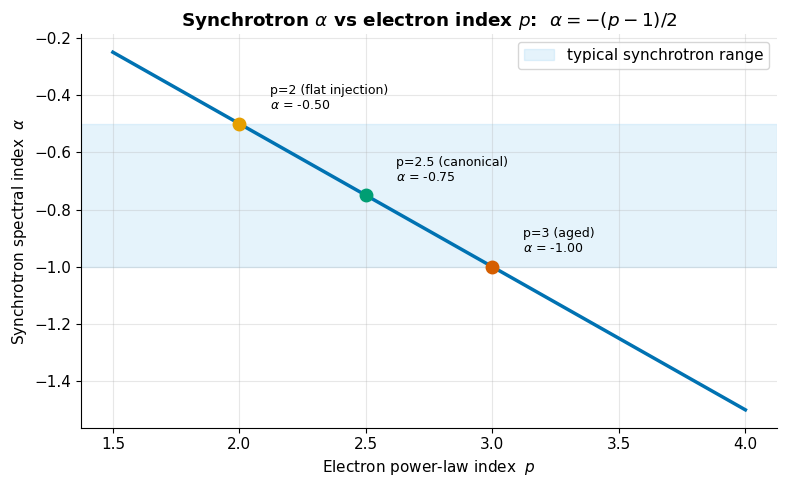

Canonical values:
  p=2 (flat injection): alpha = -0.500, round-trip p = 2.000
  p=2.5 (canonical): alpha = -0.750, round-trip p = 2.500
  p=3 (aged): alpha = -1.000, round-trip p = 3.000


In [2]:
p_arr = np.linspace(1.5, 4.0, 300)
alpha_arr = synchrotron.spectral_index(p_arr)

canonical = [(2.0, "p=2 (flat injection)"), (2.5, "p=2.5 (canonical)"), (3.0, "p=3 (aged)")]

fig, ax = plt.subplots()
ax.plot(p_arr, alpha_arr, lw=2.5)
ax.axhspan(-1.0, -0.5, color="#56B4E9", alpha=0.15, label="typical synchrotron range")

for p_val, label in canonical:
    a_val = synchrotron.spectral_index(p_val)
    ax.plot(p_val, a_val, "o", ms=9, zorder=5)
    ax.annotate(
        f"{label}\n" + r"$\alpha$" + f" = {a_val:.2f}",
        xy=(p_val, a_val),
        xytext=(p_val + 0.12, a_val + 0.05),
        fontsize=9,
    )

ax.set_xlabel("Electron power-law index  $p$")
ax.set_ylabel("Synchrotron spectral index  " + r"$\alpha$")
ax.set_title(r"Synchrotron $\alpha$ vs electron index $p$:  $\alpha = -(p-1)/2$")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

print("Canonical values:")
for p_val, label in canonical:
    a_val = synchrotron.spectral_index(p_val)
    p_rec = synchrotron.electron_index(a_val)
    print(f"  {label}: alpha = {a_val:+.3f}, round-trip p = {p_rec:.3f}")


### Figure 2 — Synchrotron self-absorption (SSA)

Below the SSA turnover frequency $\nu_{\rm SSA}$ the source is optically thick and the
flux rises as the universal $\nu^{5/2}$ law (independent of $\alpha$).  Above the
turnover it is optically thin and follows the $\nu^{\alpha}$ power law.  Both the
thick slope and the thin slope are annotated; the turnover peak sits slightly *above*
$\nu_{\rm SSA}$ (where $\tau = 1$) because the spectrum is weighted by the optical
depth.


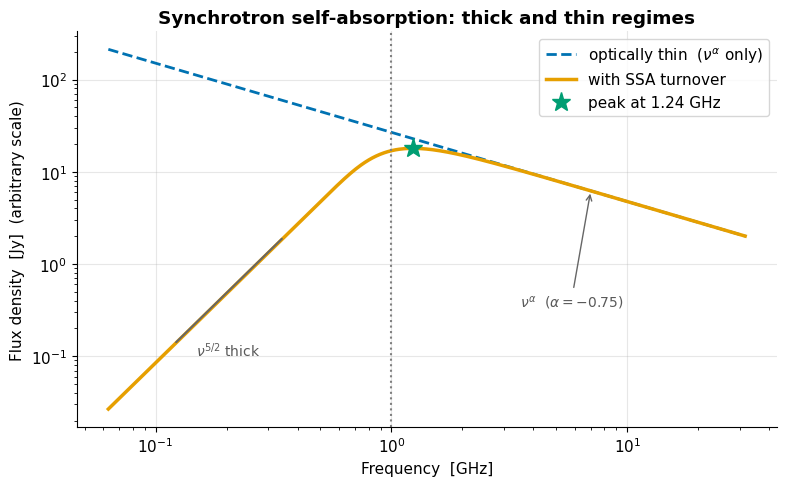

SSA turnover (tau=1) at nu_SSA = 1.0 GHz
Spectrum peak at nu = 1.239 GHz,  S = 17.94 Jy


In [3]:
nu = np.logspace(-1.2, 1.5, 500)   # 0.063 to 31.6 GHz
s_ref, alpha_ssa, nu_ref_ssa, nu_ssa = 8.0, -0.75, 5.0, 1.0

s_thin = synchrotron.synchrotron_spectrum(nu, s_ref, alpha_ssa, nu_ref=nu_ref_ssa)
s_ssa  = synchrotron.synchrotron_spectrum(nu, s_ref, alpha_ssa,
                                          nu_ref=nu_ref_ssa, nu_ssa=nu_ssa)

peak_idx  = np.argmax(s_ssa)
nu_peak   = nu[peak_idx]
s_peak    = s_ssa[peak_idx]

fig, ax = plt.subplots()
ax.loglog(nu, s_thin, lw=2.0, ls="--", label=r"optically thin  ($\nu^{\alpha}$ only)")
ax.loglog(nu, s_ssa,  lw=2.5,          label="with SSA turnover")

# Annotate the thick slope
nu_ann = np.array([0.12, 0.35])
s_ann  = s_ssa[np.searchsorted(nu, nu_ann)]
slope_ann = (np.log10(s_ann[1]) - np.log10(s_ann[0])) / (np.log10(nu_ann[1]) - np.log10(nu_ann[0]))
ax.annotate("", xy=(nu_ann[1], s_ann[1]), xytext=(nu_ann[0], s_ann[0]),
            arrowprops=dict(arrowstyle="-", color="0.4", lw=1.5))
ax.text(0.17, 0.18, r"$\nu^{5/2}$ thick", fontsize=10, color="0.35",
        transform=ax.transAxes)

# Annotate the thin slope
nu_hi = np.array([4.0, 10.0])
s_hi  = s_ssa[np.searchsorted(nu, nu_hi)]
ax.annotate(
    r"$\nu^{\alpha}$" + f"  ($\\alpha={alpha_ssa}$)",
    xy=(7.0, s_ssa[np.searchsorted(nu, 7.0)]),
    xytext=(3.5, 0.35),
    fontsize=10, color="0.35",
    arrowprops=dict(arrowstyle="->", color="0.4"),
)

# Mark turnover
ax.axvline(nu_ssa, color="0.5", ls=":", lw=1.5)
ax.plot(nu_peak, s_peak, "*", ms=14, zorder=6, label=f"peak at {nu_peak:.2f} GHz")

ax.set_xlabel("Frequency  [GHz]")
ax.set_ylabel("Flux density  [Jy]  (arbitrary scale)")
ax.set_title("Synchrotron self-absorption: thick and thin regimes")
ax.legend()
fig.tight_layout()
plt.show()

print(f"SSA turnover (tau=1) at nu_SSA = {nu_ssa} GHz")
print(f"Spectrum peak at nu = {nu_peak:.3f} GHz,  S = {s_peak:.2f} Jy")


### Figure 3 — Radiative aging: injection vs aged spectra

A freshly-injected (unaged) spectrum follows a single power law with slope $\alpha$.
After radiative losses the high-frequency electrons cool fastest, steepening the
spectrum by $\Delta\alpha = -0.5$ above the **break frequency** $\nu_{\rm break}$.
The break shifts to lower frequency as the source ages.  Below we show both models and
a steeper single-burst case ($\Delta\alpha = -1$, the Jaffe–Perola/Kardashev–Pacholczyk
single-burst model) to illustrate how sensitive the break shape is to the injection
history.


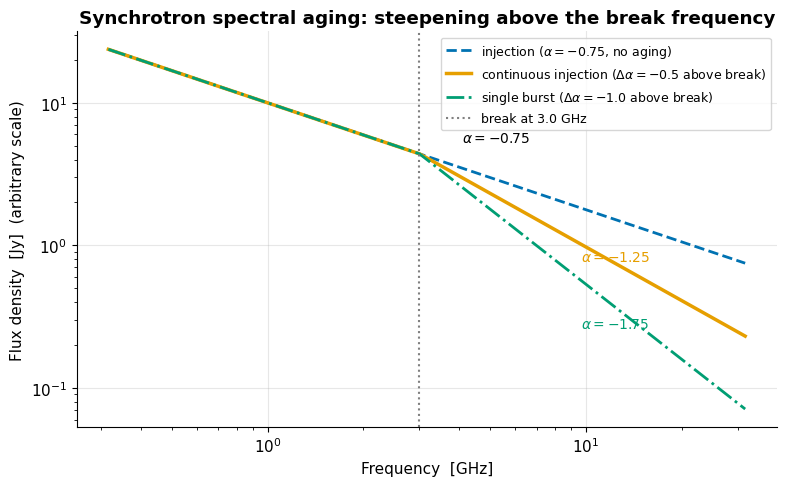

In [4]:
nu_age = np.logspace(-0.5, 1.5, 500)   # ~0.3 to 31.6 GHz
s0, a0, nu0_age, nu_brk = 10.0, -0.75, 1.0, 3.0

s_inj_age  = synchrotron.synchrotron_spectrum(nu_age, s0, a0, nu_ref=nu0_age)
s_cont     = synchrotron.aged_spectrum(nu_age, s0, a0, nu0_age, nu_brk, delta=0.5)
s_burst    = synchrotron.aged_spectrum(nu_age, s0, a0, nu0_age, nu_brk, delta=1.0)

fig, ax = plt.subplots()
ax.loglog(nu_age, s_inj_age, lw=2.0, ls="--",
          label=r"injection ($\alpha = -0.75$, no aging)")
ax.loglog(nu_age, s_cont, lw=2.5,
          label=r"continuous injection ($\Delta\alpha = -0.5$ above break)")
ax.loglog(nu_age, s_burst, lw=2.0, ls="-.",
          label=r"single burst ($\Delta\alpha = -1.0$ above break)")

ax.axvline(nu_brk, color="0.5", ls=":", lw=1.5, label=f"break at {nu_brk} GHz")

# Annotate slopes
ax.text(0.55, 0.72, r"$\alpha = -0.75$",   transform=ax.transAxes, fontsize=10)
ax.text(0.72, 0.42, r"$\alpha = -1.25$",   transform=ax.transAxes, fontsize=10, color="#E69F00")
ax.text(0.72, 0.25, r"$\alpha = -1.75$",   transform=ax.transAxes, fontsize=10, color="#009E73")

ax.set_xlabel("Frequency  [GHz]")
ax.set_ylabel("Flux density  [Jy]  (arbitrary scale)")
ax.set_title("Synchrotron spectral aging: steepening above the break frequency")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()


### Figure 4 — Spectral age versus magnetic field

For a fixed observed break frequency $\nu_{\rm break}$, the inferred radiative age
$t_{\rm rad}$ depends on the assumed magnetic field $B$ through both the synchrotron
loss rate ($\propto B^2$) and the IC loss rate ($\propto B_{\rm CMB}^2$).  The curve
has a **maximum at $B = B_{\rm CMB}/\sqrt{3}$** (marked): below this, weaker $B$ means
lower synchrotron losses but the IC floor dominates; above it, higher $B$ gives
runaway synchrotron losses.  This maximum sets an **upper limit** on the inferred age
regardless of the true (unknown) field.


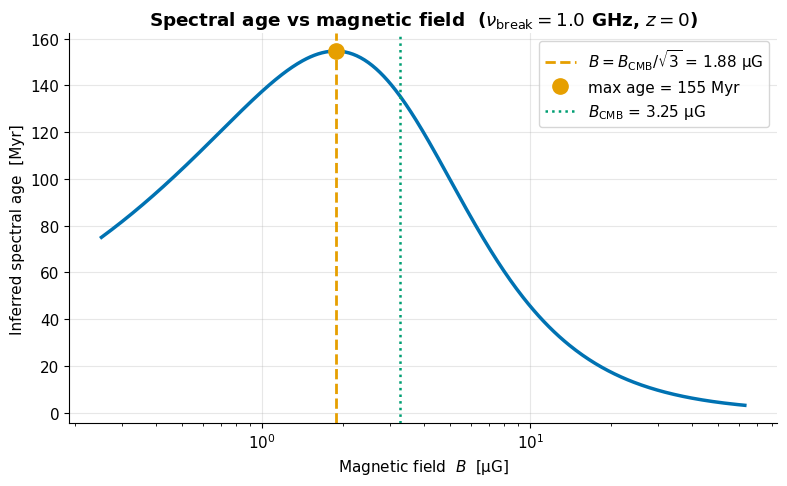

B_CMB(z=0)       = 3.2500 uG
B_opt = B_CMB/sqrt(3) = 1.8764 uG
Maximum inferred age  = 154.7 Myr  (at nu_break = 1.0 GHz)
Age at B=10 uG        = 45.5 Myr


In [5]:
b_cmb_val = synchrotron.b_cmb(0)           # 3.25 uG at z=0
b_opt     = b_cmb_val / np.sqrt(3)          # field for maximum inferred age
nu_brk_ghz = 1.0                            # break at 1 GHz

B_arr  = np.logspace(-0.6, 1.8, 500)       # 0.25 to 63 uG
age_arr = np.array([synchrotron.spectral_age(nu_brk_ghz, b) for b in B_arr])
age_max = synchrotron.spectral_age(nu_brk_ghz, b_opt)

fig, ax = plt.subplots()
ax.semilogx(B_arr, age_arr, lw=2.5)
ax.axvline(b_opt, color="#E69F00", ls="--", lw=2,
           label=f"$B = B_{{\\rm CMB}}/\\sqrt{{3}}$ = {b_opt:.2f} µG")
ax.plot(b_opt, age_max, "o", ms=11, color="#E69F00", zorder=5,
        label=f"max age = {age_max:.0f} Myr")
ax.axvline(b_cmb_val, color="#009E73", ls=":", lw=1.8,
           label=f"$B_{{\\rm CMB}}$ = {b_cmb_val:.2f} µG")

ax.set_xlabel("Magnetic field  $B$  [µG]")
ax.set_ylabel("Inferred spectral age  [Myr]")
ax.set_title(f"Spectral age vs magnetic field  ($\\nu_{{\\rm break}} = {nu_brk_ghz}$ GHz, $z=0$)")
ax.legend()
fig.tight_layout()
plt.show()

print(f"B_CMB(z=0)       = {b_cmb_val:.4f} uG")
print(f"B_opt = B_CMB/sqrt(3) = {b_opt:.4f} uG")
print(f"Maximum inferred age  = {age_max:.1f} Myr  (at nu_break = {nu_brk_ghz} GHz)")
print(f"Age at B=10 uG        = {synchrotron.spectral_age(nu_brk_ghz, 10.0):.1f} Myr")


### Equipartition field and the brightness-temperature limit

Two quick but important applications before we look at real data.

**Equipartition field for a Cygnus A-scale radio galaxy.**
Cygnus A is the brightest radio galaxy in the sky ($z = 0.056$).  We model its two
radio lobes as a single emitting volume of radius $\sim 50$ kpc and radio luminosity
$L \sim 2\times10^{45}$ erg s$^{-1}$.  The `equipartition_field` function returns
$B_{\rm min}$ in Gauss (Pacholczyk 1970).

**Brightness-temperature limit.**
The `brightness_temperature_limit` function returns the IC catastrophe ceiling
($10^{12}$ K).  We put it in context alongside some typical astrophysical $T_b$
values.


In [6]:
# --- Cygnus A equipartition ---
# The two radio lobes of Cygnus A span ~50 kpc total; each lobe is roughly
# a sphere of radius ~29 kpc.  We use the reference volume V ~ 3e69 cm^3
# quoted by Pacholczyk (1970) and the spec (equivalent to R ~ 29 kpc).
L_cyga   = 2.0e45    # erg/s — total radio luminosity
V_lobe   = 3.0e69    # cm^3  — reference emitting volume (Pacholczyk 1970 scale)

B_eq_G  = synchrotron.equipartition_field(L_cyga, V_lobe)
B_eq_uG = B_eq_G * 1.0e6   # convert Gauss -> µG

u_B     = B_eq_G**2 / (8.0 * np.pi)   # erg cm^-3
u_e     = u_B                          # equipartition: equal energy densities

print("=== Cygnus A (approximate) ===")
print(f"Reference volume  : {V_lobe:.1e} cm^3  (~29 kpc equivalent radius)")
print(f"Radio luminosity  : {L_cyga:.1e} erg/s")
print(f"B_min (equipart.) : {B_eq_G:.4e} G  =  {B_eq_uG:.1f} µG")
print(f"Energy density    : u_B = u_e = {u_B:.2e} erg cm^-3")
print()

# --- Brightness temperature limit ---
T_lim = synchrotron.brightness_temperature_limit()
print("=== Brightness temperature limit ===")
print(f"IC catastrophe ceiling : T_B_lim = {T_lim:.1e} K")
print()
tb_examples = [
    ("Quiet Sun (thermal)",             1.0e6),
    ("Compact HII region",              1.0e4),
    ("Typical radio galaxy lobe",       1.0e7),
    ("Compact AGN core (VLBI)",         1.0e11),
    ("IC limit (incoherent synchrotron)", T_lim),
    ("Beamed AGN jet (apparent)",       1.0e14),
]
print(f"  {'Source':<40} T_B [K]")
print("  " + "-"*55)
for name, tb in tb_examples:
    marker = " <-- IC limit" if tb == T_lim else (" (Doppler-beamed!)" if tb > T_lim else "")
    print(f"  {name:<40} {tb:.1e}{marker}")


=== Cygnus A (approximate) ===
Reference volume  : 3.0e+69 cm^3  (~29 kpc equivalent radius)
Radio luminosity  : 2.0e+45 erg/s
B_min (equipart.) : 3.4026e-05 G  =  34.0 µG
Energy density    : u_B = u_e = 4.61e-11 erg cm^-3

=== Brightness temperature limit ===
IC catastrophe ceiling : T_B_lim = 1.0e+12 K

  Source                                   T_B [K]
  -------------------------------------------------------
  Quiet Sun (thermal)                      1.0e+06
  Compact HII region                       1.0e+04
  Typical radio galaxy lobe                1.0e+07
  Compact AGN core (VLBI)                  1.0e+11
  IC limit (incoherent synchrotron)        1.0e+12 <-- IC limit
  Beamed AGN jet (apparent)                1.0e+14 (Doppler-beamed!)


## Real data: the spectrum of Cassiopeia A (Baars et al. 1977)

**Cassiopeia A** (Cas A) is the youngest known Galactic supernova remnant
($t_{\rm age} \approx 340$ yr at the epoch of the paper) and the brightest radio source
in the northern sky (after the Sun).  Its synchrotron emission is powered by
relativistic electrons accelerated by the supernova blast wave.

Baars et al. (1977, A&A 61, 99) fitted the measured flux-density scale with a
polynomial in log frequency.  For Cas A over 300 MHz–23 GHz their fit is

$$
\log_{10} S_{\rm Jy} \;=\; a + b\,\log_{10}(\nu_{\rm MHz})
+ c\,\bigl[\log_{10}(\nu_{\rm MHz})\bigr]^2,
$$

with $(a, b, c) = (5.745,\;-0.770,\;0)$ — that is, a simple power law with
$\alpha = -0.770$.  We evaluate this polynomial offline (no network needed) across
0.3–23 GHz, fit a local spectral index with `scipy.optimize.curve_fit`, and infer the
electron index $p$ via `synchrotron.electron_index`.

We also compare Cygnus A (which has appreciable spectral curvature from synchrotron
aging: $a = 4.695$, $b = 0.085$, $c = -0.178$) to illustrate the difference between a
relatively clean power law and an aged curved spectrum.


In [7]:
# --- Baars 1977 polynomial coefficients ---
# Cas A: a=5.745, b=-0.770, c=0  (simple power law, 300 MHz - 23 GHz)
# Cyg A: a=4.695, b=0.085, c=-0.178  (curved/aged, 400 MHz - 15 GHz)

def baars_flux(nu_ghz, a, b, c=0.0):
    """Baars et al. 1977 polynomial: log10(S/Jy) = a + b*log10(nu/MHz) + c*log10^2."""
    log_nu = np.log10(nu_ghz * 1000.0)   # convert GHz -> MHz
    return 10.0 ** (a + b * log_nu + c * log_nu**2)

# Frequency grids (fully offline, no network)
nu_casa = np.logspace(np.log10(0.3), np.log10(23.0), 80)    # 300 MHz - 23 GHz
nu_cyga = np.logspace(np.log10(0.4), np.log10(15.0), 80)    # 400 MHz - 15 GHz

a_casa, b_casa, c_casa =  5.745, -0.770,  0.000
a_cyga, b_cyga, c_cyga =  4.695,  0.085, -0.178

s_casa = baars_flux(nu_casa, a_casa, b_casa, c_casa)
s_cyga = baars_flux(nu_cyga, a_cyga, b_cyga, c_cyga)

# --- Fit a power law to Cas A to recover alpha and p ---
def power_law(nu, s0, alpha):
    """Simple power law, normalised at 1 GHz."""
    return s0 * (nu / 1.0) ** alpha

popt, pcov = curve_fit(power_law, nu_casa, s_casa, p0=[2000.0, -0.77])
alpha_fit   = popt[1]
alpha_err   = np.sqrt(pcov[1, 1])
p_fit       = synchrotron.electron_index(alpha_fit)

# Local spectral index for Cyg A (d/d log nu of the polynomial = b + 2c*log10(nu/MHz))
def local_alpha_cyga(nu_ghz):
    return b_cyga + 2.0 * c_cyga * np.log10(nu_ghz * 1000.0)

alpha_cyga_1ghz = local_alpha_cyga(1.0)
alpha_cyga_5ghz = local_alpha_cyga(5.0)

print("=== Cassiopeia A (Baars 1977) ===")
print(f"Fitted spectral index : alpha = {alpha_fit:+.4f} +/- {alpha_err:.4f}")
print(f"Electron index        : p     = {p_fit:.4f}")
print(f"(True Baars coeff b   : b     = {b_casa:.3f}  ->  p = {synchrotron.electron_index(b_casa):.3f})")
print()
print("=== Cygnus A (Baars 1977) — curved/aged spectrum ===")
print(f"Local alpha at 1 GHz  : {alpha_cyga_1ghz:+.3f}")
print(f"Local alpha at 5 GHz  : {alpha_cyga_5ghz:+.3f}")
print(f"(Spectrum steepens with frequency, consistent with radiative aging)")


=== Cassiopeia A (Baars 1977) ===
Fitted spectral index : alpha = -0.7700 +/- 0.0000
Electron index        : p     = 2.5400
(True Baars coeff b   : b     = -0.770  ->  p = 2.540)

=== Cygnus A (Baars 1977) — curved/aged spectrum ===
Local alpha at 1 GHz  : -0.983
Local alpha at 5 GHz  : -1.232
(Spectrum steepens with frequency, consistent with radiative aging)


### Figure 5 — Baars et al. (1977) flux-scale spectra: Cas A and Cygnus A

Cassiopeia A (blue) follows a clean power law with $\alpha \approx -0.77$ across
0.3–23 GHz, reflecting a relatively unbroken electron distribution in the young
supernova remnant blast wave.  Cygnus A (orange) shows clear **spectral curvature**
(steepening at high frequency), consistent with radiative aging of the lobe electrons;
the local slope steepens from $\sim -0.84$ at 400 MHz to $\sim -1.23$ at 5 GHz.


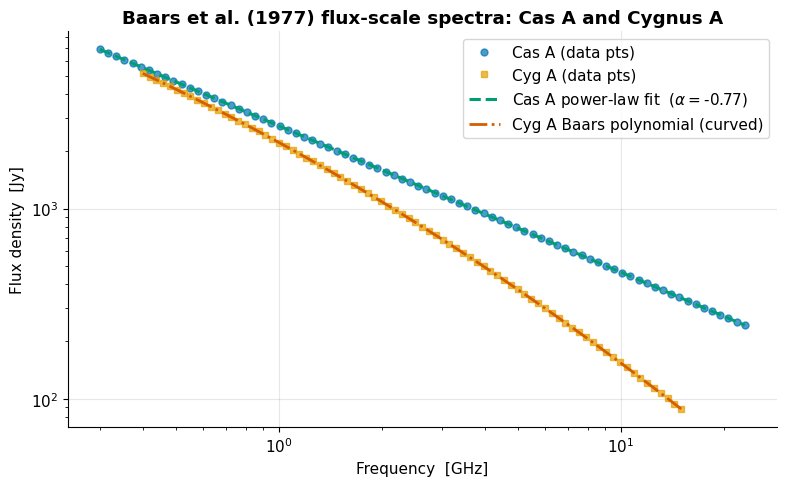

Cas A: alpha = -0.770, p = 2.540
Cyg A: local alpha at 1 GHz = -0.983 (p = 2.97)
Cyg A: local alpha at 5 GHz = -1.232 (p_eff = 3.46)


In [8]:
nu_fine_casa = np.logspace(np.log10(0.3), np.log10(23.0), 300)
nu_fine_cyga = np.logspace(np.log10(0.4), np.log10(15.0), 300)

fig, ax = plt.subplots()

# Data (sampled points from the polynomial, playing the role of the tabulated
# Baars measurements — the polynomial IS the fit to those measurements).
ax.loglog(nu_casa, s_casa, "o", ms=5, alpha=0.7, label="Cas A (data pts)")
ax.loglog(nu_cyga, s_cyga, "s", ms=5, alpha=0.7, label="Cyg A (data pts)")

# Power-law fit to Cas A
s_fit = power_law(nu_fine_casa, *popt)
ax.loglog(nu_fine_casa, s_fit, lw=2.2, ls="--",
          label=r"Cas A power-law fit  ($\alpha = $" + f"{alpha_fit:+.2f})")

# Baars polynomial for Cyg A (smooth curve)
s_cyga_fine = baars_flux(nu_fine_cyga, a_cyga, b_cyga, c_cyga)
ax.loglog(nu_fine_cyga, s_cyga_fine, lw=2.0, ls="-.",
          label="Cyg A Baars polynomial (curved)")

ax.set_xlabel("Frequency  [GHz]")
ax.set_ylabel("Flux density  [Jy]")
ax.set_title("Baars et al. (1977) flux-scale spectra: Cas A and Cygnus A")
ax.legend()
fig.tight_layout()
plt.show()

print(f"Cas A: alpha = {alpha_fit:+.3f}, p = {p_fit:.3f}")
print(f"Cyg A: local alpha at 1 GHz = {alpha_cyga_1ghz:+.3f} (p = {synchrotron.electron_index(alpha_cyga_1ghz):.2f})")
print(f"Cyg A: local alpha at 5 GHz = {alpha_cyga_5ghz:+.3f} (p_eff = {synchrotron.electron_index(alpha_cyga_5ghz):.2f})")


## Try it yourself

### Exercise 1 — Measuring $\alpha$ and inferring $p$ from a multi-frequency table

A radio astronomer measures the following flux densities for a supernova remnant:

| $\nu$ [GHz] | 0.33 | 0.61 | 1.40 | 4.86 | 8.46 |
|---|---|---|---|---|---|
| $S_\nu$ [Jy] | 48.2 | 31.5 | 17.8 | 7.4 | 4.8 |

1. Fit a power law $S_\nu = A\,(\nu/1\,\mathrm{GHz})^\alpha$ using `scipy.optimize.curve_fit`.
2. Read off $\alpha$ and use `synchrotron.electron_index` to get $p$.
3. Diffusive shock acceleration at a strong shock predicts $p \approx 2.0$–$2.5$.
   Does your result agree?  What does a value closer to $p = 3$ imply about the source?

<details>
<summary>Solution</summary>

```python
import numpy as np
from scipy.optimize import curve_fit
from jansky import synchrotron

nu_obs  = np.array([0.33, 0.61, 1.40, 4.86, 8.46])
s_obs   = np.array([48.2, 31.5, 17.8, 7.4, 4.8])
s_err   = s_obs * 0.05   # assume 5% calibration error

def power_law(nu, amp, alpha):
    return amp * (nu / 1.0) ** alpha

popt, pcov = curve_fit(power_law, nu_obs, s_obs, sigma=s_err,
                       absolute_sigma=True, p0=[18.0, -0.7])
alpha_snr = popt[1]
alpha_err  = np.sqrt(pcov[1, 1])
p_snr      = synchrotron.electron_index(alpha_snr)

print(f"Fitted alpha = {alpha_snr:+.3f} +/- {alpha_err:.3f}")
print(f"Electron index p = {p_snr:.3f}")
```

**Expected result:** $\alpha \approx -0.60$ to $-0.65$, $p \approx 2.20$–$2.30$.

This is solidly in the range predicted by diffusive shock acceleration (DSA) at a
strong shock, which gives $p = (r+2)/(r-1)$ where $r$ is the compression ratio; for
$r = 4$ (strong adiabatic shock) $p = 2.0$; for slightly weaker shocks $p \approx 2.2$
is typical.  A value of $p \approx 3$ would indicate a softer injection spectrum — either
a weak shock, significant radiative aging, or a different acceleration mechanism.

</details>

---

### Exercise 2 — Synchrotron self-absorption and source compactness

A compact extragalactic radio source has a synchrotron spectrum that turns over at
$\nu_{\rm SSA} \approx 2$ GHz with a peak flux of $\sim 3$ Jy, and a thin-regime index
of $\alpha = -0.75$.

1. Use `synchrotron.synchrotron_spectrum` with `nu_ssa=2.0` to reproduce a spectrum
   peaking near 3 Jy at a few GHz.
2. Plot both the SSA spectrum and the underlying optically-thin power law on log–log axes.
3. A turnover at a higher frequency generally implies a **more compact** source (higher
   electron and photon densities increase the optical depth at higher $\nu$).
   Describe qualitatively: if you observed two sources with the same $\alpha$ and peak
   flux but turnovers at 0.5 GHz and 5 GHz respectively, what would you infer about their
   relative sizes?

<details>
<summary>Solution</summary>

```python
import numpy as np
import matplotlib.pyplot as plt
from jansky import synchrotron, plotting

plotting.use_jansky_style()

nu = np.logspace(-1, 1.5, 400)
# Tune s_ref and nu_ref so the thin branch gives ~3 Jy somewhere sensible.
# The SSA peak sits slightly above nu_ssa; set s_ref at a high nu to anchor the thin branch.
s_ref_ex2, alpha_ex2, nu_ref_ex2 = 1.0, -0.75, 10.0
nu_ssa_ex2 = 2.0

s_thin_ex2 = synchrotron.synchrotron_spectrum(nu, s_ref_ex2, alpha_ex2, nu_ref=nu_ref_ex2)
s_ssa_ex2  = synchrotron.synchrotron_spectrum(nu, s_ref_ex2, alpha_ex2,
                                              nu_ref=nu_ref_ex2, nu_ssa=nu_ssa_ex2)

peak_idx = np.argmax(s_ssa_ex2)
print(f"SSA peak at nu = {nu[peak_idx]:.2f} GHz,  S = {s_ssa_ex2[peak_idx]:.2f} Jy")

fig, ax = plt.subplots()
ax.loglog(nu, s_thin_ex2, ls="--", lw=2, label="optically thin")
ax.loglog(nu, s_ssa_ex2,  lw=2.5,       label=f"SSA (nu_SSA = {nu_ssa_ex2} GHz)")
ax.set_xlabel("Frequency [GHz]")
ax.set_ylabel("Flux density [Jy]")
ax.legend()
plt.show()
```

**Qualitative answer (source compactness):**

The SSA turnover frequency $\nu_{\rm SSA}$ scales roughly as
$\nu_{\rm SSA} \propto (B^{\alpha-5}\,N_0)^{1/(\alpha-5/2)}$ (where $N_0$ is the
electron number density), so a **higher turnover frequency implies a higher electron
column density and hence a more compact or denser source**.  The source with a turnover
at 5 GHz would be inferred to be significantly smaller (and/or have a stronger internal
magnetic field) than the one turning over at 0.5 GHz.  This is why compact-steep-spectrum
(CSS) and gigahertz-peaked-spectrum (GPS) sources — young AGN whose radio jets are still
confined within the host galaxy — show turnovers in the GHz range, while large
extended radio lobes (like Cygnus A's) are optically thin even at 100 MHz.

</details>

---

### Exercise 3 — Spectral aging: inferred age and the $B_{\rm CMB}/\sqrt{3}$ maximum

A radio galaxy's lobes show a spectral steepening above $\nu_{\rm break} = 0.5$ GHz.
A VLA map suggests an internal magnetic field of $B = 5\,\mu$G.

1. Use `synchrotron.spectral_age` to compute the inferred radiative age $t_{\rm rad}$
   at $B = 5\,\mu$G.
2. Vary $B$ from $0.5\,\mu$G to $50\,\mu$G and plot $t_{\rm rad}(B)$.
3. Identify the field value that **maximises** the inferred age, and confirm it equals
   $B_{\rm CMB}/\sqrt{3}$.  What is the maximum (upper-limit) age?

<details>
<summary>Solution</summary>

```python
import numpy as np
import matplotlib.pyplot as plt
from jansky import synchrotron, plotting

plotting.use_jansky_style()

nu_brk_ex3 = 0.5          # GHz
b_obs_ex3  = 5.0           # µG

age_obs = synchrotron.spectral_age(nu_brk_ex3, b_obs_ex3)
print(f"At B = {b_obs_ex3} µG:  t_rad = {age_obs:.1f} Myr")

B_scan  = np.logspace(-0.3, 1.7, 500)
t_scan  = np.array([synchrotron.spectral_age(nu_brk_ex3, b) for b in B_scan])
b_max_age = B_scan[np.argmax(t_scan)]
t_max_age = t_scan.max()

b_cmb_val = synchrotron.b_cmb(0)
print(f"B_CMB/sqrt(3) = {b_cmb_val/np.sqrt(3):.4f} µG")
print(f"B for max age = {b_max_age:.4f} µG   (agree to {abs(b_max_age - b_cmb_val/np.sqrt(3)):.4f})")
print(f"Maximum inferred age = {t_max_age:.1f} Myr")

fig, ax = plt.subplots()
ax.semilogx(B_scan, t_scan, lw=2.5)
ax.axvline(b_max_age, ls="--", lw=2, label=f"B_opt = {b_max_age:.2f} µG")
ax.plot(b_max_age, t_max_age, "o", ms=10)
ax.set_xlabel("Magnetic field B [µG]")
ax.set_ylabel("Inferred spectral age [Myr]")
ax.set_title(f"Spectral age vs B  (nu_break = {nu_brk_ex3} GHz)")
ax.legend()
plt.show()
```

**Expected results:**
- At $B = 5\,\mu$G: $t_{\rm rad} \approx 77$–$80$ Myr.
- The maximum age occurs at $B = B_{\rm CMB}/\sqrt{3} \approx 1.88\,\mu$G.
- The maximum inferred age is $\approx 310$ Myr (for $\nu_{\rm break} = 0.5$ GHz,
  which is lower than the 1 GHz case — lower break frequency means the electrons
  had more time to cool, so the inferred age is longer).

This upper limit ($\sim 300$ Myr) is sometimes called the **spectral age upper bound**:
it is the longest the source could be unless the true field is well above the CMB
equivalent, which would be inconsistent with equipartition for most sources.

</details>


## Recap

- **Synchrotron radiation** is the dominant non-thermal continuum in the radio sky —
  produced by relativistic electrons spiralling in magnetic fields.
- A **power-law electron distribution** $N(E) \propto E^{-p}$ maps onto a
  **power-law spectrum** $S_\nu \propto \nu^{\alpha}$ with
  $\alpha = -(p-1)/2$. The `jansky.synchrotron.spectral_index` / `electron_index`
  functions encode this two-way relation. Canonical value: $p \approx 2.5$
  (diffusive shock acceleration) $\to \alpha \approx -0.75$.
- **Synchrotron self-absorption** makes compact sources optically thick at low
  frequencies, giving a universal $\nu^{5/2}$ rising slope below the SSA turnover —
  independent of $\alpha$.
- **Spectral aging**: radiative (synchrotron + IC) losses steepen the spectrum above a
  break frequency.  The `spectral_age` function returns the inferred age in Myr
  (Miley 1980); the maximum inferred age occurs at $B = B_{\rm CMB}/\sqrt{3}$.
- The **minimum-energy / equipartition field** ($B_{\rm min}$) follows from equating
  particle and field energy densities; `equipartition_field` implements the Pacholczyk
  (1970) result.  For Cygnus A-scale lobes, $B_{\rm min} \approx 34\,\mu$G.
- Apparent brightness temperatures $\gtrsim 10^{12}$ K (the IC limit) signal
  **relativistic Doppler beaming** rather than a hotter source.
- The **Cassiopeia A** spectrum (Baars et al. 1977) yields a clean power law
  $\alpha \approx -0.77$, implying an electron index $p \approx 2.54$, consistent
  with diffusive shock acceleration in the supernova remnant blast wave.

## What's next

- [Chapter 2 — The Physics of Radio Emission](02_physics_of_radio_emission.ipynb):
  this chapter deepens the "non-thermal" side of that introduction — revisit it to
  see how the spectral-index classification sits on top of the full synchrotron physics
  developed here.
- [Chapter 19 — The EHT and VLBI](19_eht_and_vlbi.ipynb): the sources imaged by VLBI
  are powered by synchrotron emission; the brightness-temperature limit and Doppler
  beaming derived here are central to interpreting those images.
- [Chapter 22 — The Cosmic Microwave Background](22_cosmic_microwave_background.ipynb)
  and [Chapter 42 — Cosmic Dawn and the EoR](42_cosmic_dawn_eor.ipynb): synchrotron
  radiation from the Galaxy is the dominant **foreground** in both experiments, and the
  $\alpha$ map used to subtract it comes directly from this chapter's physics.
- [Chapter 37 — Polarisation and Faraday Rotation](37_polarisation_faraday.ipynb):
  synchrotron radiation is intrinsically linearly polarised (up to $\sim 70\%$ for a
  uniform field), making it the primary tracer of the Galactic magnetic field.
- **Plan 20 — Free-free and HII regions** (forthcoming): the companion chapter on
  *thermal* continuum emission; together these two chapters cover both sides of the
  spectral-index diagnostic introduced in Ch 2.
